In [75]:
%pip install -q scikit-learn joblib seaborn torch transformers datasets accelerate


Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
data_path = "data/censorship/combined_data_corrected.csv"
df = pd.read_csv(data_path, usecols=["text", "label"])


In [31]:
if list(df.columns) != ["text", "label"]:
    raise ValueError(f"Неверный формат данных: {list(df.columns)}")


Загруженный датафрейм: (39363, 2)
Распределение классов:
label
0.0    20807
1.0    18556
Name: count, dtype: int64


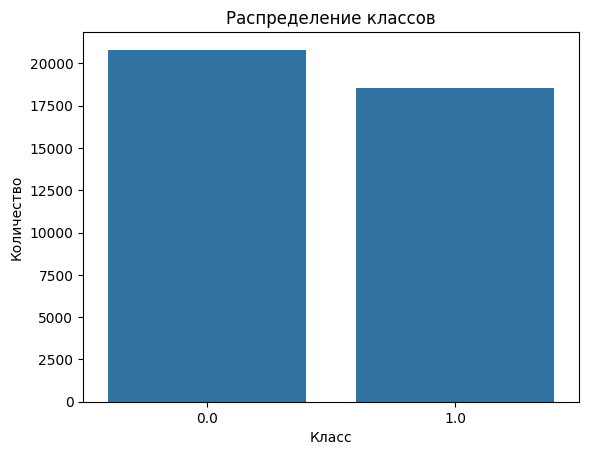

In [32]:
print(f"Загруженный датафрейм: {df.shape}")
print(f"Распределение классов:")
print(df["label"].value_counts())
sns.countplot(x="label", data=df)
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39363 entries, 0 to 39362
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    39363 non-null  object 
 1   label   39363 non-null  float64
dtypes: float64(1), object(1)
memory usage: 615.2+ KB


In [34]:
df.describe()

,label
count,39363.000000
mean,0.471407
std,0.499188
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [35]:
print("Пропуски в text:")
print(df["text"].isna().sum())
print("Дубликаты:")
print(df.duplicated().sum())
print("Дубликаты в text:")
print(df["text"].duplicated().sum())

Пропуски в text:
0
Дубликаты:
510
Дубликаты в text:
510


In [36]:
conflicts = (
    df.groupby("text")["label"]
      .nunique()
      .loc[lambda x: x > 1]
)

print("Конфликтующих текстов:", len(conflicts))
conflicts

Конфликтующих текстов: 0


Series([], Name: label, dtype: int64)

In [37]:
df_copy = df.copy()

In [38]:
df_copy["char_len"] = df["text"].fillna("").str.len()
df_copy["word_len"] = df["text"].fillna("").str.split().str.len()

df_copy[["char_len", "word_len"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

,char_len,word_len
count,39363.000000,39363.000000
mean,150.609811,21.780632
std,188.642641,27.865742
min,3.000000,1.000000
50%,98.000000,15.000000
90%,325.000000,43.000000
95%,357.000000,49.000000
99%,718.000000,114.000000
max,7404.000000,1078.000000


<Axes: xlabel='word_len', ylabel='Count'>

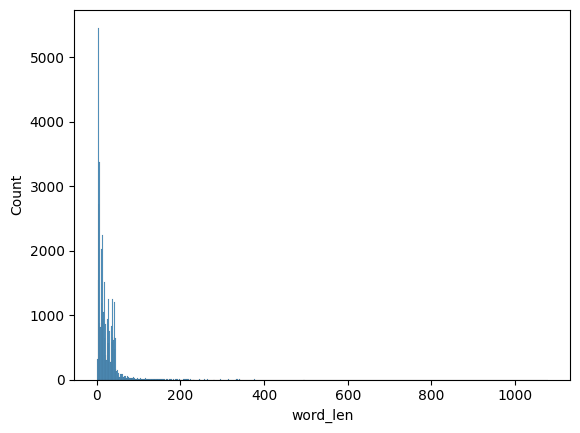

In [39]:
sns.histplot(df_copy["word_len"])

In [40]:
df_copy.loc[
    df_copy["word_len"] > 150,
    ["text", "label", "word_len"]
].sort_values(
    "word_len",
    ascending=False
).head(30)

,text,label,word_len
1963,"В Киеве на вокзале Мен було рок в 19, коли мен...",1.0,1078
2074,С начала года свыше 40 тысяч россиян объявили ...,0.0,1012
3026,"Блеаадь, как же обидно когда создаешь тред, па...",1.0,787
5805,С 19 апреля в Николаеве будет действовать запр...,0.0,741
214,"Раз уж вакханалия продолжается, давайте в этом...",1.0,678
669,"Знаете, моя подруга живёт с мужчиной, который ...",1.0,676
1638,"именно так. смотрю на тебя, стаса, вестника ду...",1.0,666
9215,"Рад, что Вы допускаете пользу от маркетинга. В...",0.0,658
13698,Агентство DARPA в 2020 году планирует начать р...,0.0,611
496,"та ну, хуйня это все про джентельменство . мен...",1.0,605


In [43]:
for threshold in [50, 100, 150, 300, 500]:
    count = (df_copy["word_len"] > threshold).sum()
    share = count / len(df_copy)

    print(
        f"больше {threshold} слов: {count} "
        f"({share:.2%})"
    )

больше 50 слов: 1846 (4.69%)
больше 100 слов: 488 (1.24%)
больше 150 слов: 226 (0.57%)
больше 300 слов: 59 (0.15%)
больше 500 слов: 15 (0.04%)


In [44]:
df_copy.loc[df_copy["word_len"] > 150, ["text", "label", "word_len"]].sort_values("word_len", ascending=False).head(30)

,text,label,word_len
1963,"В Киеве на вокзале Мен було рок в 19, коли мен...",1.0,1078
2074,С начала года свыше 40 тысяч россиян объявили ...,0.0,1012
3026,"Блеаадь, как же обидно когда создаешь тред, па...",1.0,787
5805,С 19 апреля в Николаеве будет действовать запр...,0.0,741
214,"Раз уж вакханалия продолжается, давайте в этом...",1.0,678
669,"Знаете, моя подруга живёт с мужчиной, который ...",1.0,676
1638,"именно так. смотрю на тебя, стаса, вестника ду...",1.0,666
9215,"Рад, что Вы допускаете пользу от маркетинга. В...",0.0,658
13698,Агентство DARPA в 2020 году планирует начать р...,0.0,611
496,"та ну, хуйня это все про джентельменство . мен...",1.0,605


Baseline

In [57]:
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

features = FeatureUnion([
    (
        "word",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
        ),
    ),
    (
        "char",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
        ),
    ),
], verbose=True)

model = Pipeline([
    ("features", features),
    ("classifier", LogisticRegression(max_iter=2000)),
], verbose=True)

In [58]:
x = df["text"]
y = df["label"]

In [59]:
x_train_val, x_test, y_train_val, y_test = sklearn.model_selection.train_test_split(
    x,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
x_train, x_val, y_train, y_val = sklearn.model_selection.train_test_split(
    x_train_val,
    y_train_val,
    test_size=1/9,
    random_state=42,
    stratify=y_train_val
)
len(x_train), len(x_val), len(x_test)

(31489, 3937, 3937)

In [60]:
from sklearn.metrics import classification_report, confusion_matrix
model.fit(x_train, y_train)
y_val_pred = model.predict(x_val)
print(classification_report(y_val, y_val_pred, digits=4))

[FeatureUnion] .......... (step 1 of 2) Processing word, total=   2.2s
[FeatureUnion] .......... (step 2 of 2) Processing char, total=  11.3s
[Pipeline] .......... (step 1 of 2) Processing features, total=  13.7s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   3.0s
              precision    recall  f1-score   support

         0.0     0.9216    0.9601    0.9405      2081
         1.0     0.9531    0.9084    0.9302      1856

    accuracy                         0.9357      3937
   macro avg     0.9373    0.9343    0.9353      3937
weighted avg     0.9364    0.9357    0.9356      3937



подбор гипер параметров

In [61]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    "features__word__ngram_range": [
        (1, 1),
        (1, 2),
    ],
    "features__word__min_df": [1, 2, 3, 5],
    "features__word__max_df": [0.95, 0.98, 1.0],
    "features__word__sublinear_tf": [True, False],

    "features__char__ngram_range": [
        (3, 5),
        (3, 6),
        (2, 5),
    ],
    "features__char__min_df": [1, 2, 3, 5],
    "features__char__sublinear_tf": [True, False],

    "classifier__C": loguniform(0.05, 20),
    "classifier__class_weight": [None, "balanced"],
}

In [63]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    verbose=2,
    random_state=42,
    refit=True,
    return_train_score=True,
)

search.fit(x_train, y_train)

print(search.best_params_)
print(search.best_score_)

best_model = search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[FeatureUnion] .......... (step 1 of 2) Processing word, total=   5.9s
[FeatureUnion] .......... (step 2 of 2) Processing char, total=  13.0s
[Pipeline] .......... (step 1 of 2) Processing features, total=  19.2s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   1.5s
[CV] END classifier__C=0.47156966780898374, classifier__class_weight=None, features__char__min_df=3, features__char__ngram_range=(2, 5), features__char__sublinear_tf=False, features__word__max_df=0.95, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__sublinear_tf=False; total time=  25.7s
[FeatureUnion] .......... (step 1 of 2) Processing word, total=   0.8s
[FeatureUnion] .......... (step 2 of 2) Processing char, total=   9.6s
[Pipeline] .......... (step 1 of 2) Processing features, total=  10.5s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   1.9s
[CV] END classifier__C=0.47156966780898374, classifi

In [64]:
print(search.best_params_)
print(search.best_score_)

{'classifier__C': 5.109721406106862, 'classifier__class_weight': 'balanced', 'features__char__min_df': 5, 'features__char__ngram_range': (2, 5), 'features__char__sublinear_tf': True, 'features__word__max_df': 1.0, 'features__word__min_df': 1, 'features__word__ngram_range': (1, 2), 'features__word__sublinear_tf': True}
0.9882799824698237


In [ ]:
best_model.predict(x_train)

подбор порога

In [65]:
import re

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)


def split_into_sentences(text: str) -> list[str]:
    if not isinstance(text, str):
        return []

    sentences = re.split(r"(?<=[.!?])\s+", text.strip())

    return [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]


def get_message_scores(
    model,
    messages,
) -> np.ndarray:
    """
    Для каждого сообщения:
    1. разбивает его на предложения;
    2. получает вероятность токсичности каждого предложения;
    3. возвращает максимальную вероятность.
    """

    all_sentences = []
    message_ranges = []

    for message in messages:
        sentences = split_into_sentences(message)

        # Чтобы пустое сообщение не потерялось
        if not sentences:
            sentences = [""]

        start = len(all_sentences)
        all_sentences.extend(sentences)
        end = len(all_sentences)

        message_ranges.append((start, end))

    # Все предложения передаются модели одним батчем
    sentence_scores = model.predict_proba(all_sentences)[:, 1]

    message_scores = []

    for start, end in message_ranges:
        score = sentence_scores[start:end].max()
        message_scores.append(score)

    return np.asarray(message_scores)

In [67]:
message_scores = get_message_scores(
    model=best_model,
    messages=x_val,
)

message_scores[:10]

array([1.85020118e-06, 5.42541042e-03, 9.99581185e-01, 7.08502300e-03,
       1.82117900e-01, 4.28819485e-06, 1.97563483e-02, 9.99971071e-01,
       1.53808264e-01, 7.75277863e-06])

In [68]:
def find_best_threshold(
    y_true,
    scores,
    beta: float = 1.0,
):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        scores,
    )

    # У precision и recall на один элемент больше,
    # чем у thresholds
    precision = precision[:-1]
    recall = recall[:-1]

    f_beta = (
        (1 + beta**2) * precision * recall
        / (
            beta**2 * precision
            + recall
            + 1e-12
        )
    )

    best_index = np.argmax(f_beta)

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "f_beta": float(f_beta[best_index]),
    }

In [69]:
result = find_best_threshold(
    y_true=y_val,
    scores=message_scores,
    beta=1,
)

print("Лучший threshold:", result["threshold"])
print("Precision:", result["precision"])
print("Recall:", result["recall"])
print("F1:", result["f_beta"])

Лучший threshold: 0.6331059542406778
Precision: 0.9312026002166848
Recall: 0.9261853448275862
F1: 0.9286871961097106


In [71]:
best_threshold = result["threshold"]

message_predictions = (
    message_scores >= best_threshold
).astype(int)

print(
    classification_report(
        y_val,
        message_predictions,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_val,
        message_predictions,
    )
)

              precision    recall  f1-score   support

         0.0     0.9345    0.9390    0.9367      2081
         1.0     0.9312    0.9262    0.9287      1856

    accuracy                         0.9329      3937
   macro avg     0.9328    0.9326    0.9327      3937
weighted avg     0.9329    0.9329    0.9329      3937

Confusion matrix:
[[1954  127]
 [ 137 1719]]


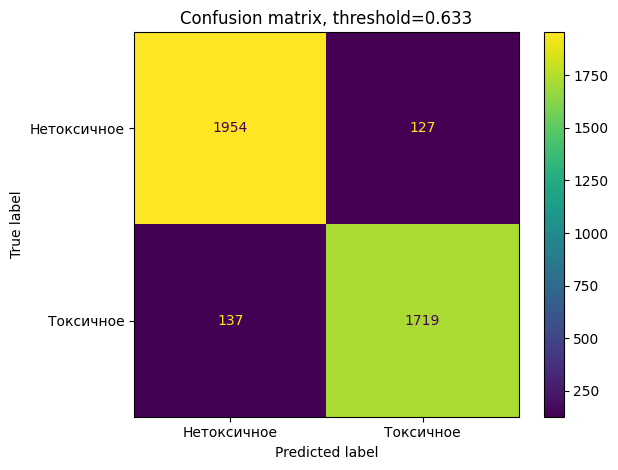

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_true=y_val,
    y_pred=message_predictions,
    display_labels=["Нетоксичное", "Токсичное"],
    values_format="d",
)

plt.title(f"Confusion matrix, threshold={best_threshold:.3f}")
plt.tight_layout()
plt.show()

Финальная проверка best_model на тестовой выборке

In [74]:
# Тестовая выборка используется только для финальной оценки.
# Модель и порог уже выбраны на train/validation.
test_scores = get_message_scores(
    model=best_model,
    messages=x_test,
)

test_predictions = (
    test_scores >= best_threshold
).astype(int)

print(f"Test samples: {len(y_test)}")
print(f"Validation threshold: {best_threshold:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions))

Test samples: 3937
Validation threshold: 0.6331
              precision    recall  f1-score   support

         0.0     0.9445    0.9486    0.9465      2081
         1.0     0.9421    0.9375    0.9398      1856

    accuracy                         0.9434      3937
   macro avg     0.9433    0.9430    0.9432      3937
weighted avg     0.9434    0.9434    0.9434      3937

Confusion matrix:
[[1974  107]
 [ 116 1740]]


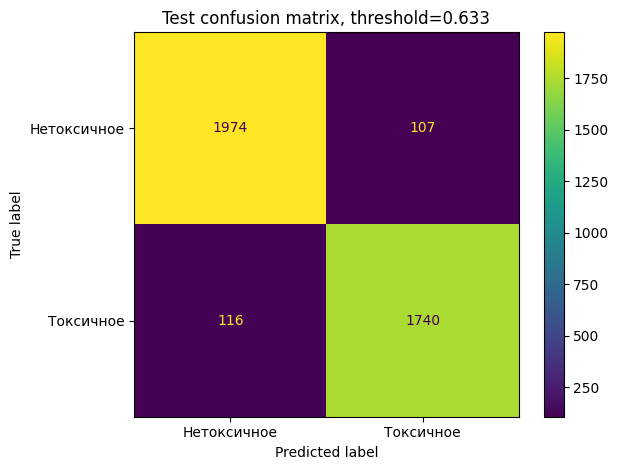

In [75]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=test_predictions,
    display_labels=["Нетоксичное", "Токсичное"],
    values_format="d",
)

plt.title(f"Test confusion matrix, threshold={best_threshold:.3f}")
plt.tight_layout()
plt.show()

Экспорт best_model через joblib

In [76]:
from pathlib import Path

import joblib


artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)
model_path = artifacts_dir / "best_model.joblib"

model_artifact = {
    "vectorizer": best_model.named_steps["features"],
    "model": best_model.named_steps["classifier"],
    "threshold": float(best_threshold),
}

joblib.dump(model_artifact, model_path)
print(f"Модель сохранена: {model_path.resolve()}")

Модель сохранена: C:\Users\Дарья\Documents\programming_projects\alfacasebot\alfacasebot\ml\artifacts\best_model.joblib
